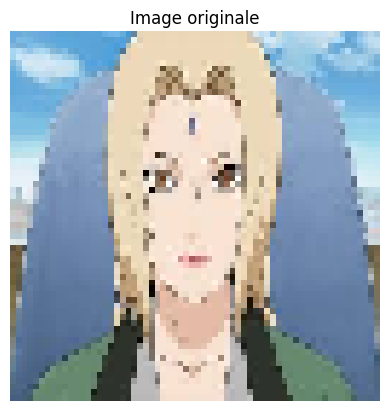

In [5]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 64

img_path = "image_bruitee.png"

img = image.load_img(
    img_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = image.img_to_array(img)

# normalisation
img_array = img_array.astype("float32") / 255.

plt.imshow(img_array)
plt.title("Image originale")
plt.axis("off")
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def denoise_image(path, model, img_size=64, show=True):
    """
    Charge une image, la normalise, applique un autoencoder
    et retourne + affiche l'image débruitée.

    Parameters
    ----------
    path : str
        chemin de l'image
    model : keras.Model
        modèle entraîné (autoencoder / U-Net)
    img_size : int
        taille d'entrée du modèle
    show : bool
        afficher ou non les images

    Returns
    -------
    denoised_img : numpy array (H, W, 3)
    """

    # 1. Charger image
    img = image.load_img(path, target_size=(img_size, img_size))
    # img_array = image.img_to_array(img).astype("float32") / 255.0

    # 2. Ajouter batch dimension
    img_input = np.expand_dims(img_array, axis=0)

    # 3. Prédiction
    denoised = model.predict(img_input, verbose=0)[0]

    # 4. Nettoyage sortie
    denoised = np.clip(denoised, 0, 1)

    # 5. Affichage
    if show:
        plt.figure(figsize=(9,3))

        plt.subplot(1,3,1)
        plt.imshow(img_array)
        plt.title("Input")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(img_array)  # bruitée ou originale selon ton pipeline
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(denoised)
        plt.title("Denoised")
        plt.axis("off")

        plt.show()

    return denoised

In [9]:
from tensorflow.keras.models import load_model

autoencoder = load_model("model_denoising.h5")

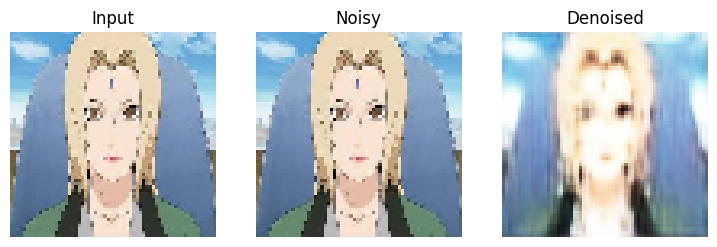

In [10]:
denoised = denoise_image("image_bruitee.png", autoencoder, img_size=64)